In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import Subset
from PIL import Image
import os

# Define your paths again so this notebook knows where to look
train_dir = 'data/train'
test_dir = 'data/test'

# Set device (use GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [23]:
# --- AUGMENTATION DESIGNER PIPELINE ---
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomResizedCrop(48, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5), # Requirement: Horizontal Flip
    transforms.RandomRotation(20),          # Requirement: Rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Requirement: Brightness
    transforms.ToTensor(),
    # --- DATA MANAGER REQUIREMENT: Convert to RGB (3-channel) ---
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# --- DATA MANAGER REQUIREMENT: Load and Split ---
# 1. Load the full training folder
full_train_dataset = datasets.ImageFolder(root='data/train', transform=train_transform)

# 2. Split into Train (80%) and Validation (20%)
# stratify=full_train_dataset.targets ensures the emotion balance is preserved
train_idx, val_idx = train_test_split(
    range(len(full_train_dataset)),
    test_size=0.2,
    stratify=full_train_dataset.targets,
    random_state=42
)

# 3. Create the Subsets
train_data = Subset(full_train_dataset, train_idx)
val_data = Subset(full_train_dataset, val_idx) # This is your 'practice exam' set
test_dataset = datasets.ImageFolder(root='data/test', transform=test_transform)

# 4. Initialize DataLoaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Data Manager: Split Complete.")
print(f"Training: {len(train_data)} | Validation: {len(val_data)} | Test: {len(test_dataset)}")

Data Manager: Split Complete.
Training: 22967 | Validation: 5742 | Test: 7178


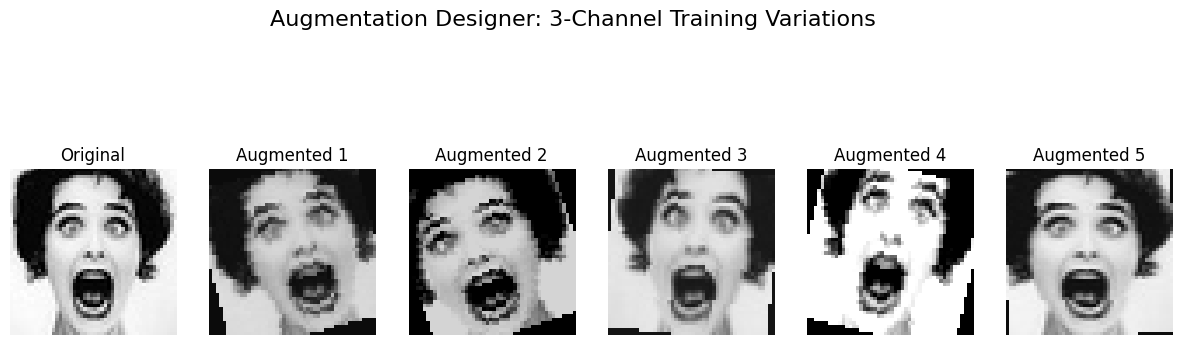

In [24]:
def visualize_augmentations(dataset, idx=0):
    plt.figure(figsize=(15, 5))
    
    # --- THE FIX FOR SUBSETS ---
    # If the dataset is a Subset, we need to find the real index in the original folder
    if isinstance(dataset, torch.utils.data.Subset):
        actual_idx = dataset.indices[idx]
        base_dataset = dataset.dataset
    else:
        actual_idx = idx
        base_dataset = dataset

    # 1. Show Original
    img_path, _ = base_dataset.samples[actual_idx]
    original_img = Image.open(img_path).convert('L')
    plt.subplot(1, 6, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # 2. Show Augmented Versions
    for i in range(5):
        aug_tensor, _ = dataset[idx] # This still pulls the augmented version correctly
        
        # Convert from [3, 48, 48] to [48, 48, 3]
        aug_img = aug_tensor.numpy().transpose(1, 2, 0)
        
        # Undo the normalization for display
        aug_img = (aug_img * 0.5) + 0.5 
        aug_img = np.clip(aug_img, 0, 1) # Safety check for brightness/contrast
        
        plt.subplot(1, 6, i + 2)
        plt.imshow(aug_img) 
        plt.title(f"Augmented {i+1}")
        plt.axis('off')
    
    plt.suptitle("Augmentation Designer: 3-Channel Training Variations", fontsize=16)
    plt.show()

visualize_augmentations(train_data, idx=0)